<a href="https://colab.research.google.com/github/pxu/Generative_Deep_Learning_2nd_Edition/blob/main/notebooks/04_gan/03_cgan/cgan-project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤪 Conditional WGAN-GP on CelebA Faces - Train

In this notebook, we'll walk through the steps required to train your own Conditional GAN on the CelebA faces dataset

The code has been adapted from the excellent [CGAN tutorial](https://keras.io/examples/generative/conditional_gan/) created by Sayak Paul, available on the Keras website.

In [16]:
# %load_ext autoreload
# %autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras import (
    layers,
    models,
    callbacks,
    utils,
    metrics,
    optimizers,
)

In [17]:
import matplotlib.pyplot as plt


def sample_batch(dataset):
    batch = dataset.take(1).get_single_element()
    if isinstance(batch, tuple):
        batch = batch[0]
    return batch.numpy()


def display(
    images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
):
    """
    Displays n random images from each one of the supplied arrays.
    """
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()

## 0. Parameters <a name="parameters"></a>

In [18]:
IMAGE_SIZE = 64
CHANNELS = 3
CLASSES = 2
BATCH_SIZE = 128
Z_DIM = 32
LEARNING_RATE = 0.00005
ADAM_BETA_1 = 0.5
ADAM_BETA_2 = 0.999
EPOCHS = 20
CRITIC_STEPS = 3
GP_WEIGHT = 10.0
LOAD_MODEL = False
ADAM_BETA_1 = 0.5
ADAM_BETA_2 = 0.9
LABEL = "Blond_Hair"

## 1. Prepare the data <a name="prepare"></a>

In [19]:
# Load the label dataset
attributes = pd.read_csv("/content/list_attr_celeba.csv")
print(attributes.columns)
attributes.head()

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young'],
      dtype='object')


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


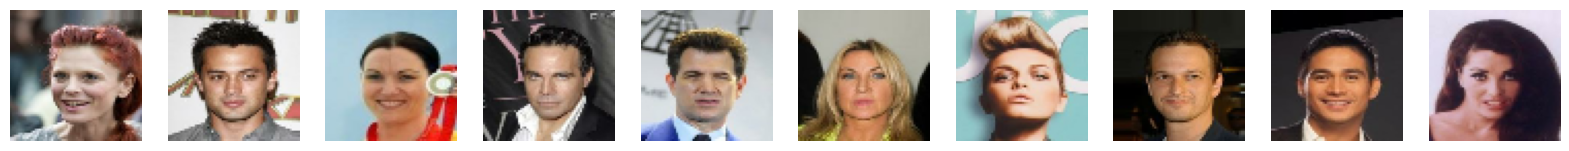

In [20]:
# =============================
# Correct CelebA label + image loading
# =============================

labels_raw = attributes[LABEL].tolist()
int_labels = [1 if x == 1 else 0 for x in labels_raw]

IMG_DIR = "/content/img_align_celeba"


# -------------------------
# 1. Define load_image_and_label FIRST
# -------------------------
def load_image_and_label(filename, label):
    path = tf.strings.join([IMG_DIR, "/", filename])
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    image = (tf.cast(image, tf.float32) - 127.5) / 127.5
    return image, tf.one_hot(label, depth=CLASSES)

# 1. 强制文件名排序
filenames = sorted(os.listdir(IMG_DIR))

# 2. 建立 CSV → 标签 map
csv_filenames = attributes["image_id"].tolist()
csv_map = dict(zip(csv_filenames, int_labels))

# 3. 让标签严格与 filenames 对齐
aligned_labels = [csv_map[fname] for fname in filenames]

# 4. Dataset
train = (
    tf.data.Dataset.from_tensor_slices((filenames, aligned_labels))
    .map(load_image_and_label, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(20000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# 5. 預覽 sample（確保不是灰色）
train_sample = sample_batch(train)
display(train_sample, cmap=None)

## 2. Build the GAN <a name="build"></a>

In [21]:
# ============================
# FINAL — Correct Critic Model
# ============================

critic_image_input = layers.Input(
    shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS),
    name="critic_image_input"
)

# IMPORTANT: Critic MUST accept the broadcasted label mask
critic_label_input = layers.Input(
    shape=(IMAGE_SIZE, IMAGE_SIZE, 1),
    name="critic_label_input"
)

# Combine image + label mask
concat = layers.Concatenate(axis=-1)([critic_image_input, critic_label_input])

# Convolutional stack
x = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(concat)
x = layers.LeakyReLU(0.2)(x)

x = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(0.3)(x)

x = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(0.3)(x)

x = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(0.3)(x)

# Final 1×1 output for WGAN-GP
x = layers.Conv2D(1, kernel_size=4, strides=1, padding="valid")(x)
critic_output = layers.Flatten()(x)

critic = models.Model(
    [critic_image_input, critic_label_input],
    critic_output,
    name="critic"
)

critic.summary()

Model: "critic"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ critic_image_input  │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ critic_label_input  │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64, 4) │          0 │ critic_image_inp… │
│ (Concatenate)       │                   │            │ critic_label_inp… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      4,160 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 32, 32,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │    131,200 │ leaky_re_lu[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ leaky_re_lu_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │    262,272 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 8, 8, 128) │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8, 8, 128) │          0 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 4, 4, 128) │    262,272 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 4, 4, 128) │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 4, 4, 128) │          0 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 1, 1, 1)   │      2,049 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ conv2d_4[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 661,953 (2.53 MB)

 Trainable params: 661,953 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
generator_input = layers.Input(shape=(Z_DIM,))
label_input = layers.Input(shape=(CLASSES,))
x = layers.Concatenate(axis=-1)([generator_input, label_input])
x = layers.Reshape((1, 1, Z_DIM + CLASSES))(x)
x = layers.Conv2DTranspose(
    128, kernel_size=4, strides=1, padding="valid", use_bias=False
)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Conv2DTranspose(
    128, kernel_size=4, strides=2, padding="same", use_bias=False
)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Conv2DTranspose(
    128, kernel_size=4, strides=2, padding="same", use_bias=False
)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Conv2DTranspose(
    64, kernel_size=4, strides=2, padding="same", use_bias=False
)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
generator_output = layers.Conv2DTranspose(
    CHANNELS, kernel_size=4, strides=2, padding="same", activation="tanh"
)(x)
generator = models.Model([generator_input, label_input], generator_output)
generator.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 34)        │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 34)  │          0 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 4, 4, 128) │     69,632 │ reshape[0][0]     │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4, 4, 128) │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 4, 4, 128) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 8, 8, 128) │    262,144 │ leaky_re_lu_4[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 16, 16,    │    262,144 │ leaky_re_lu_5[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 32, 32,    │    131,072 │ leaky_re_lu_6[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 64, 64, 3) │      3,075 │ leaky_re_lu_7[0]… │
│ (Conv2DTranspose)   │                   │            │                 

 Total params: 729,859 (2.78 MB)

 Trainable params: 728,963 (2.78 MB)

 Non-trainable params: 896 (3.50 KB)

In [23]:
class ConditionalWGAN(models.Model):
    def __init__(self, critic, generator, latent_dim, critic_steps, gp_weight):
        super(ConditionalWGAN, self).__init__()
        self.critic = critic
        self.generator = generator
        self.latent_dim = latent_dim
        self.critic_steps = critic_steps
        self.gp_weight = gp_weight

    def compile(self, c_optimizer, g_optimizer):
        super(ConditionalWGAN, self).compile(run_eagerly=True)
        self.c_optimizer = c_optimizer
        self.g_optimizer = g_optimizer
        self.c_wass_loss_metric = metrics.Mean(name="c_wass_loss")
        self.c_gp_metric = metrics.Mean(name="c_gp")
        self.c_loss_metric = metrics.Mean(name="c_loss")
        self.g_loss_metric = metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [
            self.c_loss_metric,
            self.c_wass_loss_metric,
            self.c_gp_metric,
            self.g_loss_metric,
        ]

    # gradient penalty (unchanged)
    def gradient_penalty(self, batch_size, real_images, fake_images, label_mask):
        alpha = tf.random.normal([batch_size, 1, 1, 1], 0.0, 1.0)
        diff = fake_images - real_images
        interpolated = real_images + alpha * diff

        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            pred = self.critic([interpolated, label_mask], training=True)

        grads = gp_tape.gradient(pred, [interpolated])[0]
        norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
        gp = tf.reduce_mean((norm - 1.0) ** 2)
        return gp

    # -------------------------
    # FIXED train_step
    # -------------------------

    def train_step(self, data):
        real_images, one_hot_labels = data
        batch_size = tf.shape(real_images)[0]

        # ============================================================
        # FIXED: Create 1‑channel label mask for Critic
        # ============================================================
        label_mask = one_hot_labels[:, :1]   # (batch,1)
        label_mask = tf.reshape(label_mask, (-1, 1, 1, 1))
        label_mask = tf.tile(label_mask, [1, IMAGE_SIZE, IMAGE_SIZE, 1])
        # ============================================================

        # ============================================================

        # --------------------------
        # Train critic
        # --------------------------
        for _ in range(self.critic_steps):
            random_latent_vectors = tf.random.normal(
                shape=(batch_size, self.latent_dim)
            )

            with tf.GradientTape() as tape:
                # produce fake images
                fake_images = self.generator(
                    [random_latent_vectors, one_hot_labels], training=True
                )

                # critic predictions
                fake_preds = self.critic(
                    [fake_images, label_mask], training=True
                )
                real_preds = self.critic(
                    [real_images, label_mask], training=True
                )

                # WGAN critic loss
                c_wass_loss = tf.reduce_mean(fake_preds) - tf.reduce_mean(real_preds)

                # gradient penalty
                c_gp = self.gradient_penalty(
                    batch_size, real_images, fake_images, label_mask
                )

                # total critic loss
                c_loss = c_wass_loss + self.gp_weight * c_gp

            # update critic
            c_grads = tape.gradient(c_loss, self.critic.trainable_variables)
            self.c_optimizer.apply_gradients(zip(c_grads, self.critic.trainable_variables))

        # --------------------------
        # Train generator
        # --------------------------
        random_latent_vectors = tf.random.normal(
            shape=(batch_size, self.latent_dim)
        )

        with tf.GradientTape() as tape:
            fake_images = self.generator(
                [random_latent_vectors, one_hot_labels], training=True
            )
            fake_preds = self.critic(
                [fake_images, label_mask], training=True
            )
            g_loss = -tf.reduce_mean(fake_preds)

        g_grads = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(
            zip(g_grads, self.generator.trainable_variables)
        )

        # metrics
        self.c_loss_metric.update_state(c_loss)
        self.c_wass_loss_metric.update_state(c_wass_loss)
        self.c_gp_metric.update_state(c_gp)
        self.g_loss_metric.update_state(g_loss)

        return {m.name: m.result() for m in self.metrics}

In [24]:
# Create a GAN
cgan = ConditionalWGAN(
    critic=critic,
    generator=generator,
    latent_dim=Z_DIM,
    critic_steps=CRITIC_STEPS,
    gp_weight=GP_WEIGHT,
)

In [25]:
if LOAD_MODEL:
    cgan.load_weights("./checkpoint/checkpoint.ckpt")

## 3. Train the GAN <a name="train"></a>

In [26]:
# Compile the GAN
cgan.compile(
    c_optimizer=optimizers.Adam(
        learning_rate=LEARNING_RATE, beta_1=ADAM_BETA_1, beta_2=ADAM_BETA_2
    ),
    g_optimizer=optimizers.Adam(
        learning_rate=LEARNING_RATE, beta_1=ADAM_BETA_1, beta_2=ADAM_BETA_2
    ),
)

In [27]:
class GeneratorCheckpoint(callbacks.Callback):
    def __init__(self, gen, filepath):
        super().__init__()
        self.gen = gen
        self.filepath = filepath

    def on_epoch_end(self, epoch, logs=None):
        self.gen.save_weights(self.filepath.format(epoch=epoch))
        print(f"\nSaved generator weights at epoch {epoch}")


In [28]:
# Create a model save checkpoint
# model_checkpoint_callback = callbacks.ModelCheckpoint(
#     filepath="./checkpoint/checkpoint.weights.h5",
#     save_weights_only=True,
#     save_freq="epoch",
#     verbose=0,
# )





# model_checkpoint_callback = callbacks.ModelCheckpoint(
#     filepath="./checkpoint/generator.weights.h5",
#     save_weights_only=True,
#     save_freq="epoch",
#     verbose=1,
# )

# # 绑定到真正的模型上
# model_checkpoint_callback.model = cgan.generator


tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img, latent_dim):
        self.num_img = num_img
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):
        # latent vectors tensor
        random_latent_vectors = tf.random.normal(
            shape=(self.num_img, self.latent_dim)
        )

        # =========================
        # label = 0, one-hot [1, 0]
        # =========================
        zero_label = tf.constant(
            np.repeat([[1, 0]], self.num_img, axis=0),
            dtype=tf.float32
        )

        generated_images = self.model.generator(
            [random_latent_vectors, zero_label]
        )
        generated_images = generated_images * 127.5 + 127.5
        generated_images = generated_images.numpy()

        display(
            generated_images,
            save_to=f"./output/generated_img_{epoch:03d}_label_0.png",
            cmap=None,
        )

        # =========================
        # label = 1, one-hot [0, 1]
        # =========================
        one_label = tf.constant(
            np.repeat([[0, 1]], self.num_img, axis=0),
            dtype=tf.float32
        )

        generated_images = self.model.generator(
            [random_latent_vectors, one_label]
        )
        generated_images = generated_images * 127.5 + 127.5
        generated_images = generated_images.numpy()

        display(
            generated_images,
            save_to=f"./output/generated_img_{epoch:03d}_label_1.png",
            cmap=None,
        )

Epoch 1/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - c_gp: 0.7339 - c_loss: 7.0263 - c_wass_loss: -0.3124 - g_loss: 0.1820
Saved generator weights at epoch 0

Saved to ./output/generated_img_000_label_0.png


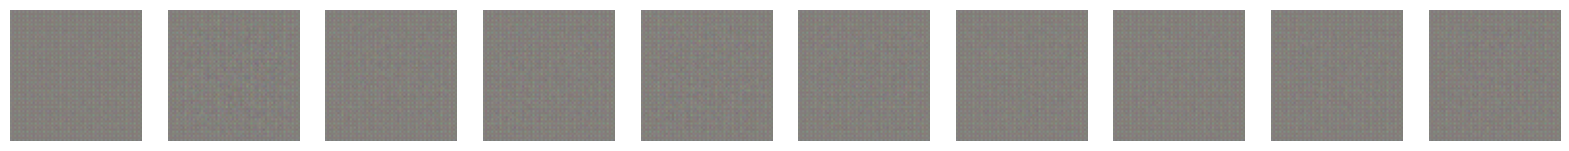


Saved to ./output/generated_img_000_label_1.png


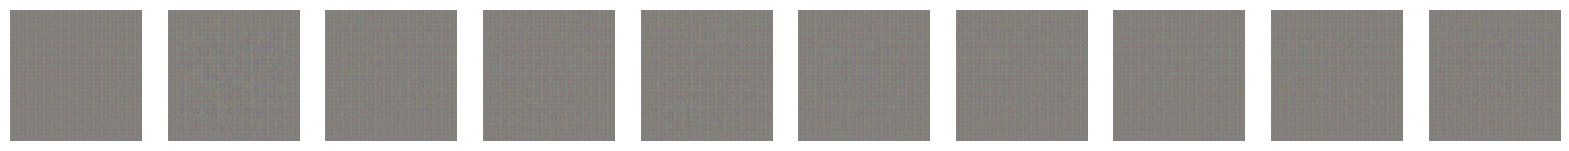

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - c_gp: 0.7339 - c_loss: 7.0263 - c_wass_loss: -0.3124 - g_loss: 0.1820
Epoch 2/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - c_gp: 0.7222 - c_loss: 6.8320 - c_wass_loss: -0.3895 - g_loss: 0.2809
Saved generator weights at epoch 1

Saved to ./output/generated_img_001_label_0.png


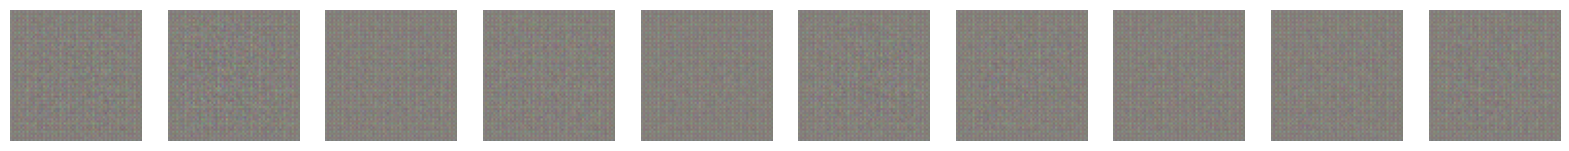


Saved to ./output/generated_img_001_label_1.png


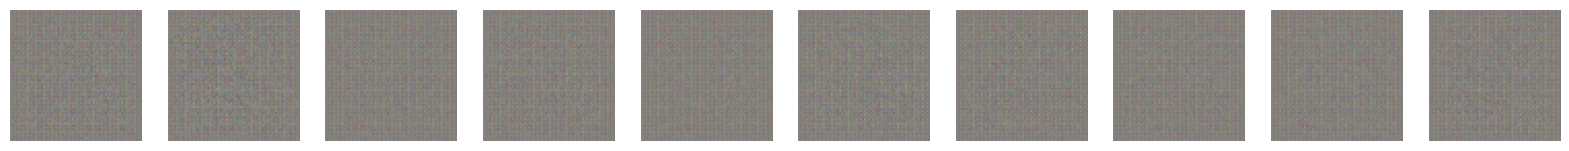

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - c_gp: 0.7222 - c_loss: 6.8320 - c_wass_loss: -0.3895 - g_loss: 0.2809
Epoch 3/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - c_gp: 0.7070 - c_loss: 6.4928 - c_wass_loss: -0.5767 - g_loss: 0.3919
Saved generator weights at epoch 2

Saved to ./output/generated_img_002_label_0.png


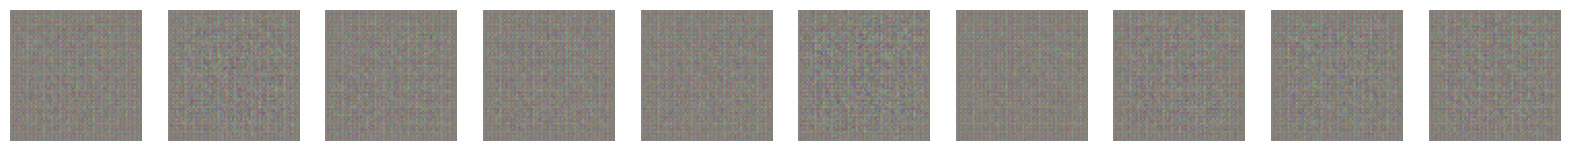


Saved to ./output/generated_img_002_label_1.png


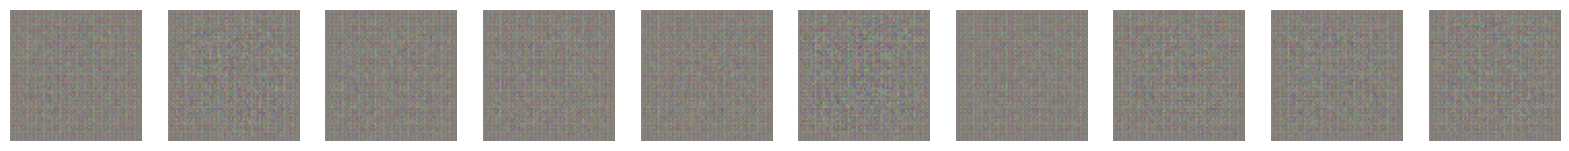

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - c_gp: 0.7070 - c_loss: 6.4928 - c_wass_loss: -0.5767 - g_loss: 0.3919
Epoch 4/2000


KeyboardInterrupt: 

In [32]:

if not os.path.exists("checkpoint"):
    os.makedirs("checkpoint")

if not os.path.exists("output"):
    os.makedirs("output")


gen_ckpt = GeneratorCheckpoint(
    gen=cgan.generator,
    filepath="./checkpoint/generator.{epoch:04d}.weights.h5",
)

history = cgan.fit(
    train,
    epochs=EPOCHS * 100,
    steps_per_epoch=1,
    callbacks=[
        gen_ckpt,
        tensorboard_callback,
        ImageGenerator(num_img=10, latent_dim=Z_DIM),
    ],
)

In [ ]:
import os

# Create the models directory if it doesn't exist
if not os.path.exists('./models/'):
    os.makedirs('./models/')

# Save the final models
generator.save("./models/generator.keras")
critic.save("./models/critic.keras")

## Generate images

In [ ]:
# 0 label
z_sample = np.random.normal(size=(10, Z_DIM))
class_label = np.repeat([[1, 0]], 10, axis=0)
imgs = cgan.generator.predict([z_sample, class_label])
display(imgs, cmap=None)

In [ ]:
# 1 label
z_sample = np.random.normal(size=(10, Z_DIM))
class_label = np.repeat([[0, 1]], 10, axis=0)
imgs = cgan.generator.predict([z_sample, class_label])
display(imgs, cmap=None)